<a href="https://colab.research.google.com/github/LinglinNero/MSSP607/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#connect to github file
from google.colab import userdata
import os

github_token = userdata.get('Git_Hub')
owner = 'LinglinNero' # Replace with the GitHub repository owner
repository = 'MSSP607' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
!git clone {clone_url}

Cloning into 'MSSP607'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 176 (delta 75), reused 34 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (176/176), 7.49 MiB | 4.14 MiB/s, done.
Resolving deltas: 100% (75/75), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

In [4]:
#data overview
df = pd.read_csv('/content/drive/MyDrive/MSSP607/Assignments/Assignment2/InternetSales.csv', encoding= 'latin1')
df.info()
#missing value
missing = df.isnull().sum()
print(missing)
#category
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
print(list(categorical_cols))

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))


/tmp/ipython-input-3257335703.py:2: DtypeWarning: Columns (11,14,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/MSSP607/Assignments/Assignment2/InternetSales.csv', encoding= 'latin1')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60376 entries, 0 to 60375
Data columns (total 61 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        60376 non-null  int64  
 1   CustomerKey               60376 non-null  int64  
 2   GeographyKey              60376 non-null  int64  
 3   City                      60376 non-null  object 
 4   CountryRegionCode         60376 non-null  object 
 5   EnglishCountryRegionName  60376 non-null  object 
 6   CustomerAlternateKey      60376 non-null  object 
 7   Title                     307 non-null    object 
 8   FirstName                 60376 non-null  object 
 9   MiddleName                34897 non-null  object 
 10  LastName                  60376 non-null  object 
 11  NameStyle                 60376 non-null  object 
 12  BirthDate                 60376 non-null  object 
 13  MaritalStatus             60321 non-null  object 
 14  Suffix

In [5]:
#Data preparation
pd.set_option('display.float_format', '{:,.2f}'.format)
#order date
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors = 'coerce')
df['Year'] = df['OrderDate'].dt.year

#sales
df['SalesAmount'] = pd.to_numeric(
    df['SalesAmount'].astype(str)
                     .str.replace(r'[^\d\.\-]', '', regex=True)
                     .str.replace(r'^\.$', '', regex=True),
    errors='coerce'
)
#na
df.dropna(subset=['OrderDate','SalesAmount','EnglishCountryRegionName'], inplace = True)

/tmp/ipython-input-4174844071.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_table = table_df.applymap(lambda x: f"${x:,.2f}")


EnglishCountryRegionName      Australia         Canada         France  \
Year                                                                    
2,010.00                     $20,909.78      $3,578.27      $3,399.99   
2,011.00                  $2,309,720.35    $524,267.99    $283,513.03   
2,012.00                  $1,907,754.86    $296,341.34    $396,943.07   
2,013.00                  $4,085,639.11  $1,018,736.64  $1,066,118.01   
2,014.00                      $8,210.65      $7,877.65      $3,631.22   
 Total                    $8,332,234.75  $1,850,801.89  $1,753,605.32   

EnglishCountryRegionName        Germany United Kingdom  United States  \
Year                                                                    
2,010.00                          $0.00        $699.10     $14,833.90   
2,011.00                    $307,777.75    $358,762.19  $2,229,984.05   
2,012.00                    $395,046.84    $489,841.79  $1,340,104.27   
2,013.00                  $1,207,282.13  $1,530,37

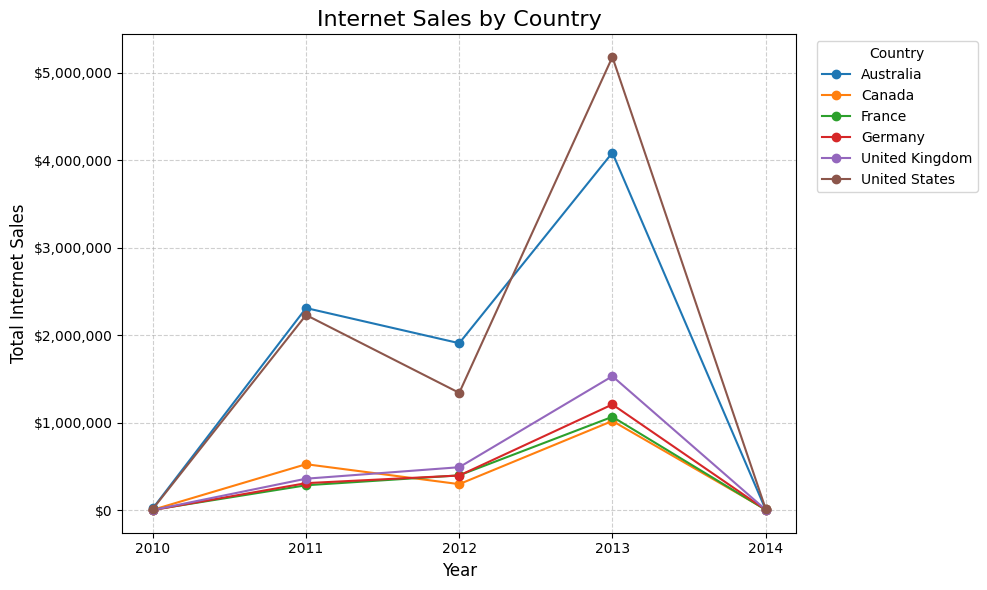

In [6]:
# Internet sales of Adventure Works by year for each Country Region
yearly_sales_Counrty = df.groupby(['Year', 'EnglishCountryRegionName'])['SalesAmount'].sum().reset_index()
pivot_df = yearly_sales_Counrty.pivot(
    index = 'Year',
    columns = 'EnglishCountryRegionName',
    values = 'SalesAmount'
).fillna(0)

table_df = pivot_df.copy()

table_df['Total'] = table_df.sum(axis=1)
table_df.loc['Total'] = table_df.sum(axis=0)
formatted_table = table_df.applymap(lambda x: f"${x:,.2f}")
print(formatted_table)

plt.figure(figsize = (10, 6))
ax = plt.gca()

for col in pivot_df.columns:
    plt.plot(
        pivot_df.index,
        pivot_df[col],
        'o-',
        label= col
    )

plt.title('Internet Sales by Country', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Internet Sales', fontsize=12)
plt.xticks(pivot_df.index)

def currency_formatter(y, pos):
    return f'${y:,.0f}'
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [7]:
#summary statistics including min, max, and standard deviation for Yearly Income, Gender by Country Regions
valid_gender = ['M', 'F']
df_valid = df[df['Gender'].isin(valid_gender)]
df_valid.dropna(subset=['YearlyIncome', 'Gender', 'EnglishCountryRegionName'])

income_stats = df_valid.groupby(['EnglishCountryRegionName', 'Gender'])['YearlyIncome'].agg(
    min_income='min',
    max_income='max',
    std_dev_income='std',
    mean_income='mean'
).reset_index()

income_stats['min_income'] = income_stats['min_income'].apply(lambda x: f"${x:,.0f}")
income_stats['max_income'] = income_stats['max_income'].apply(lambda x: f"${x:,.0f}")
income_stats['std_dev_income'] = income_stats['std_dev_income'].apply(lambda x: f"${x:,.2f}")
income_stats['mean_income'] = income_stats['mean_income'].apply(lambda x: f"${x:,.2f}")

print(income_stats)


   EnglishCountryRegionName Gender min_income max_income std_dev_income  \
0                 Australia      F    $10,000   $160,000     $30,613.96   
1                 Australia      M    $10,000   $170,000     $32,550.78   
2                    Canada      F    $10,000   $170,000     $19,435.16   
3                    Canada      M    $10,000   $170,000     $22,788.74   
4                    France      F    $10,000   $110,000     $28,051.35   
5                    France      M    $10,000   $110,000     $28,674.26   
6                   Germany      F    $10,000   $130,000     $37,622.81   
7                   Germany      M    $10,000   $130,000     $37,413.00   
8            United Kingdom      F    $10,000   $170,000     $51,130.69   
9            United Kingdom      M    $10,000   $170,000     $50,963.71   
10            United States      F    $10,000   $170,000     $25,498.81   
11            United States      M    $10,000   $170,000     $26,542.59   

   mean_income  
0   $67

In [8]:
#average price of the product category that generates the most sales
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors = 'coerce')
df.dropna(subset=['UnitPrice','EnglishProductName'], inplace = True)

def pro_category(product_name):
  if' - ' in product_name:
    return product_name.split(' - ')[0].strip()
  elif ',' in product_name:
    return product_name.split(',')[0].strip()
  else:
    return product_name.strip()

df['ProductCategory'] = df['EnglishProductName'].apply(pro_category)


def product_model(product_color):
  colors = ['Black', 'Silver', 'Red', 'Yellow', 'Blue', 'White', 'Grey']
  words = product_color.split(' ')
  if len(words) > 1 and words[-1] in colors:
    return ' '.join(words[:-1]).strip()
  else:
    return product_color

df['ProductModel'] = df['ProductCategory'].apply(product_model)

category_counts = df['ProductModel'].value_counts()
print(category_counts)

category_sales = df.groupby('ProductModel')['SalesAmount'].sum()
category_avg_price = df.groupby('ProductModel')['UnitPrice'].mean()
top_categories = category_sales.sort_values(ascending = False).head(10)

tops_10_df = pd.DataFrame({
    'Total Sales': top_categories,
    'Average Price': category_avg_price[top_categories.index]
})

print(tops_10_df)

ProductModel
Sport-100 Helmet       5365
Water Bottle           3600
Mountain-200           3077
Mountain Tire Tube     2749
Patch Kit/8 Patches    2720
                       ... 
20110515                  1
20120105                  1
20120619                  1
20120423                  1
20120404                  1
Name: count, Length: 947, dtype: int64
              Total Sales  Average Price
ProductModel                            
Mountain-200 6,874,554.64       2,234.17
Road-150     4,630,281.38       3,578.27
Road-250     3,638,933.51       2,344.67
Touring-1000 2,744,064.57       2,384.07
Road-350-W   1,246,825.67       1,700.99
Road-550-W   1,217,292.33       1,088.81
Mountain-100 1,181,971.51       3,386.74
Road-750       581,029.24         539.99
Road-650       497,002.90         762.27
Touring-2000   334,083.75       1,214.85


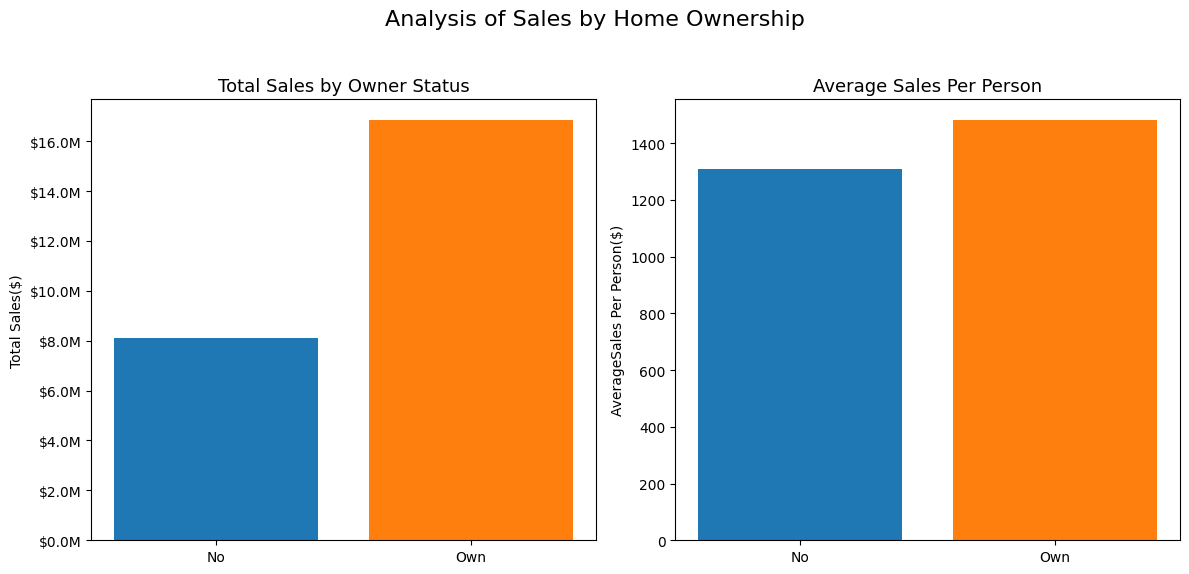

                Total Sales Total People Total Transactions  \
OwnerStatus                                                   
No            $8,118,026.20        6,212             20,204   
Own          $16,833,596.95       11,374             37,404   

            AverageSales_PerPerson Averagetime_PerPerson  
OwnerStatus                                               
No                       $1,306.83            3.25 times  
Own                      $1,480.01            3.29 times  


In [9]:
#owning a home impact
df['HouseOwnerFlag'] = pd.to_numeric(df['HouseOwnerFlag'], errors = 'coerce')
df.dropna(subset=['HouseOwnerFlag'], inplace = True)

df = df[df['HouseOwnerFlag'].isin([0, 1])].copy()
df['OwnerStatus'] = df['HouseOwnerFlag'].map({0: 'No', 1: 'Own'})

OwnerStatus_sales = df.groupby('OwnerStatus')['SalesAmount'].sum()
OwnerStatus_sales.name = 'Total Sales'

total_ppl = df.groupby('OwnerStatus')['CustomerKey'].nunique()
total_ppl.name = 'Total People'

total_transactions = df.groupby('OwnerStatus')['SalesAmount'].count()
total_transactions.name = 'Total Transactions'

intotal = pd.concat([OwnerStatus_sales, total_ppl, total_transactions], axis = 1)

intotal['AverageSales_PerPerson'] = round(intotal['Total Sales'] / intotal['Total People'], 2)
intotal['Averagetime_PerPerson'] = round(intotal['Total Transactions'] / intotal['Total People'], 2)

plot_data = intotal.reset_index()
fig,(ax1, ax2) = plt.subplots(1, 2, figsize = (12, 6))
colors = ['#1f77b4', '#ff7f0e']
ax1.bar(plot_data['OwnerStatus'], plot_data['Total Sales'], color = colors)
ax1.set_title('Total Sales by Owner Status', fontsize = 13)
ax1.set_ylabel('Total Sales($)')

def currency_formatter_millions(y, pos):
    return f'${y/1_000_000:,.1f}M'
ax1.yaxis.set_major_formatter(FuncFormatter(currency_formatter_millions))

ax2.bar(plot_data['OwnerStatus'], plot_data['AverageSales_PerPerson'], color = colors)
ax2.set_title('Average Sales Per Person', fontsize = 13)
ax2.set_ylabel('AverageSales Per Person($)')

fig.suptitle('Analysis of Sales by Home Ownership', fontsize = 16)
plt.tight_layout(rect = [0, 0.03, 1, 0.95])
plt.show()

intotal_formatted = intotal.copy()

intotal_formatted['Total Sales'] = intotal_formatted['Total Sales'].apply(lambda x: f"${x:,.2f}")
intotal_formatted['Total People'] = intotal_formatted['Total People'].apply(lambda x: f"{x:,.0f}")
intotal_formatted['Total Transactions'] = intotal_formatted['Total Transactions'].apply(lambda x: f"{x:,.0f}")
intotal_formatted['AverageSales_PerPerson'] = intotal_formatted['AverageSales_PerPerson'].apply(lambda x: f"${x:,.2f}")
intotal_formatted['Averagetime_PerPerson'] = intotal_formatted['Averagetime_PerPerson'].apply(lambda x: f"{x:.2f} times")
print(intotal_formatted)